# PRODIGY_DS_01 — Data Visualization
**Task:** Create a bar chart or histogram to visualize the distribution of a categorical or continuous variable (e.g. population/age/gender distribution).

**Dataset:** World Bank Total Population indicator (World Development Indicators), as provided by Prodigy InfoTech.
Source: https://github.com/Prodigy-InfoTech/data-science-datasets/tree/main/Task%201

**Author:** Ishaan Singh Chauhan


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110


## 1. Load the data

In [2]:
# The World Bank CSV has 4 metadata rows before the actual header
df = pd.read_csv("population.csv", skiprows=4)
meta = pd.read_csv("metadata_country.csv")

LATEST_YEAR = "2024"
df.head()


,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,Unnamed: 69
0,Aruba,ABW,"Population, total",SP.POP.TOTL,54922.0,55578.0,56320.0,57002.0,57619.0,58190.0,...,108727.0,108735.0,108908.0,109203.0,108587.0,107700.0,107310.0,107359.0,107624.0,NaN
1,Africa Eastern and Southern,AFE,"Population, total",SP.POP.TOTL,130075728.0,133534923.0,137171659.0,140945536.0,144904094.0,149033472.0,...,623369401.0,640058741.0,657801085.0,675950189.0,694446100.0,713090928.0,731821393.0,750503764.0,769294618.0,NaN
2,Afghanistan,AFG,"Population, total",SP.POP.TOTL,9035043.0,9214083.0,9404406.0,9604487.0,9814318.0,10036008.0,...,34700612.0,35688935.0,36743039.0,37856121.0,39068979.0,40000412.0,40578842.0,41454761.0,42647492.0,NaN
3,Africa Western and Central,AFW,"Population, total",SP.POP.TOTL,97630925.0,99706674.0,101854756.0,104089175.0,106388440.0,108772632.0,...,429454743.0,440882906.0,452195915.0,463365429.0,474569351.0,485920997.0,497387180.0,509398589.0,521764076.0,NaN
4,Angola,AGO,"Population, total",SP.POP.TOTL,5231654.0,5301583.0,5354310.0,5408320.0,5464187.0,5521981.0,...,29183070.0,30234839.0,31297155.0,32375632.0,33451132.0,34532429.0,35635029.0,36749906.0,37885849.0,NaN


## 2. Clean the data
The raw file mixes real countries with aggregate regions (e.g. "World", "South Asia").
We use the metadata file's `Region` column to keep only actual countries.

In [3]:
country_codes = meta.loc[meta["Region"].notna(), "Country Code"]
countries_df = df[df["Country Code"].isin(country_codes)].copy()

countries_df = countries_df[["Country Name", "Country Code", LATEST_YEAR]]
countries_df = countries_df.dropna(subset=[LATEST_YEAR])
countries_df[LATEST_YEAR] = countries_df[LATEST_YEAR].astype(float)

print(f"Countries with valid {LATEST_YEAR} data: {len(countries_df)}")
countries_df[LATEST_YEAR].describe()


Countries with valid 2024 data: 217


count    2.170000e+02
mean     3.741310e+07
std      1.428311e+08
min      9.646000e+03
25%      8.310870e+05
50%      6.587202e+06
75%      2.703241e+07
max      1.450936e+09
Name: 2024, dtype: float64

## 3. Bar Chart — Top 15 Most Populous Countries

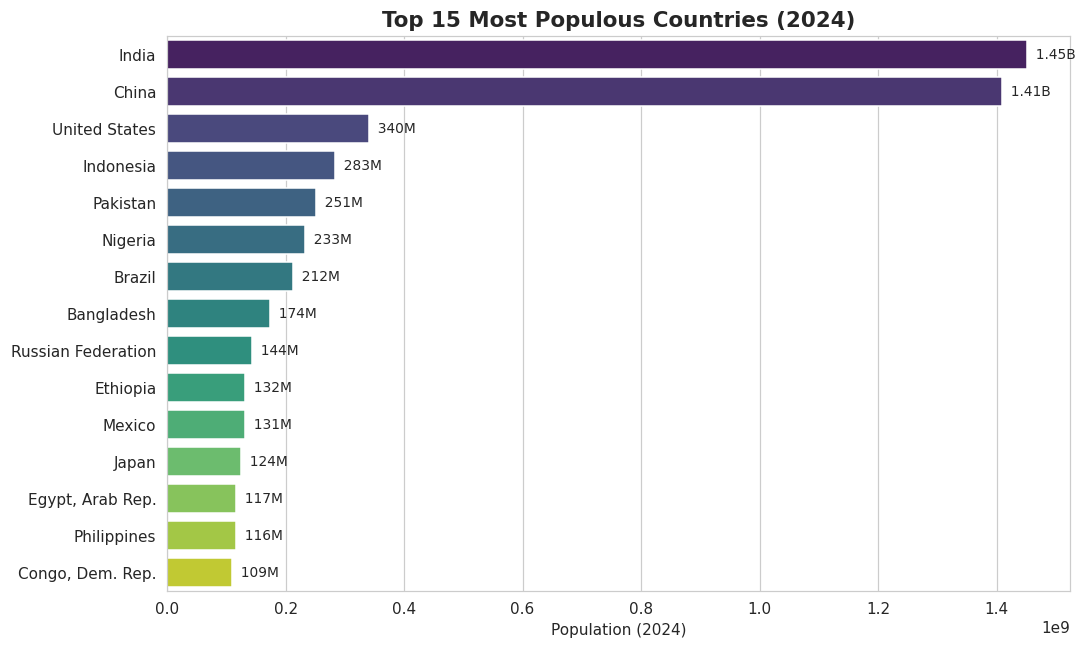

In [4]:
top15 = countries_df.sort_values(LATEST_YEAR, ascending=False).head(15)

plt.figure(figsize=(10, 6))
ax = sns.barplot(data=top15, x=LATEST_YEAR, y="Country Name",
                  hue="Country Name", palette="viridis", legend=False)
ax.set_xlabel("Population (2024)")
ax.set_ylabel("")
ax.set_title("Top 15 Most Populous Countries (2024)", fontsize=14, weight="bold")

for i, val in enumerate(top15[LATEST_YEAR]):
    label = f"{val/1e9:.2f}B" if val >= 1e9 else f"{val/1e6:.0f}M"
    ax.text(val, i, f"  {label}", va="center", fontsize=9)

plt.tight_layout()
plt.savefig("chart1_top15_countries_bar.png", bbox_inches="tight")
plt.show()


## 4. Histogram — Distribution of Population Across All Countries
Population size is heavily right-skewed (a handful of countries are extremely large),
so a log10 transform reveals the true shape of the distribution.

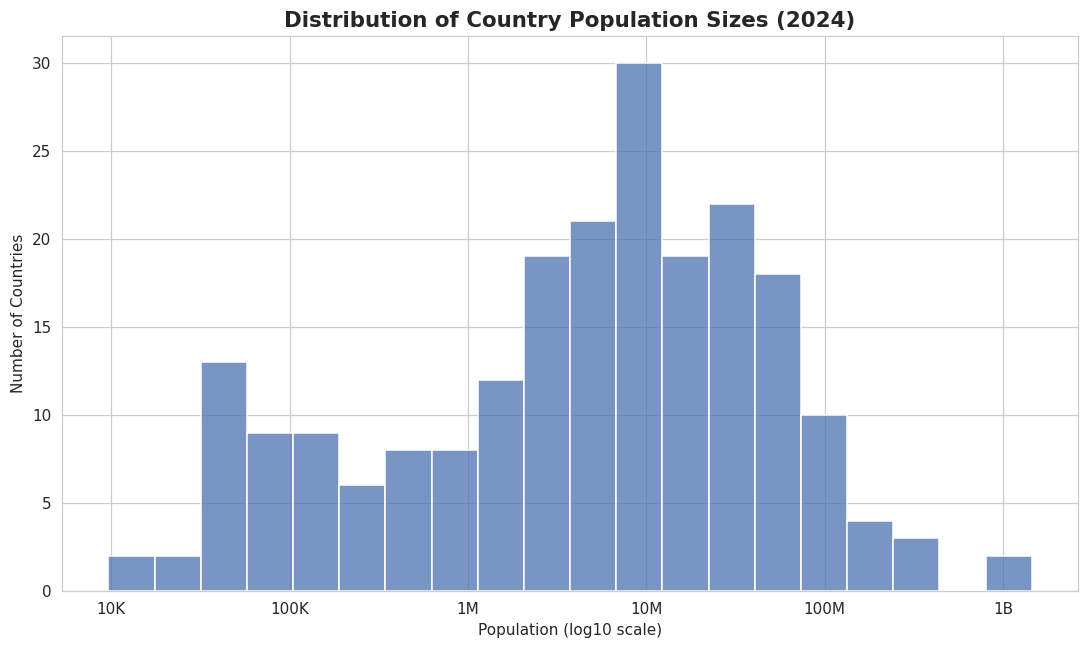

In [5]:
countries_df["log_pop"] = np.log10(countries_df[LATEST_YEAR])

plt.figure(figsize=(10, 6))
sns.histplot(countries_df["log_pop"], bins=20, color="#4C72B0", edgecolor="white")
plt.xlabel("Population (log10 scale)")
plt.ylabel("Number of Countries")
plt.title("Distribution of Country Population Sizes (2024)", fontsize=14, weight="bold")

tick_vals = [4, 5, 6, 7, 8, 9]
tick_labels = ["10K", "100K", "1M", "10M", "100M", "1B"]
plt.xticks(tick_vals, tick_labels)

plt.tight_layout()
plt.savefig("chart2_population_histogram.png", bbox_inches="tight")
plt.show()


## 5. Key Insights
- Global population (2024) across 217 countries ranges from ~9,600 (smallest) to ~1.45 billion (largest).
- The **median** country has ~6.6 million people, while the **mean** (~37.4 million) is pulled far higher by a small number of very large countries — a classic right-skewed distribution.
- India and China alone account for a disproportionate share of world population, visible clearly in the bar chart.
- The log-scale histogram shows most countries cluster between 100K and 100M in population, confirming that "very large" countries are the exception, not the rule.
